## Ascend versus A100

In [1]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

sns.set_context('paper', font_scale=2., rc={"lines.linewidth": 1.75} )
sns.set_style({'font.weight': 'bold'})

# Markers
plt.rcParams['lines.markersize'] = 6.5
plt.rcParams['lines.linewidth'] = 1.75
plt.rcParams['figure.figsize'] = (8.7,6.27)

_LEGEND_MARKER_SCALE = 1.75
_MARKERS = ["o", "^", "s", "X"]

_SNS_PARAMS = {"hue":'S', "style":'S', "markers":_MARKERS, "dashes":True}


In [2]:
# Select plot parameters

# dtype = "int8"
dtype = "fp16"
tiles = [32, 64, 128]

In [3]:
def add_stats_siso(df, nbytes_out_dtype: int):
    # Input number of bytes per element
    df["in_bytes_per_elem"] = df["dtype"].map({"fp16": 2, "int8": 1})

    df["mem_bytes"] = df["size"] * (df["in_bytes_per_elem"] + nbytes_out_dtype)
    
    df["gelemps"] = (df["size"] / 1e9) / (df["time_us"] / 1e6)
    df["bw_gbps"] = ( df["mem_bytes"] / 1e9) / (df["time_us"] / 1e6)

In [4]:
PREFIX_PATH = "../../.."

df_copy = pd.read_csv(f"{PREFIX_PATH}/bench_results_copy_{dtype}.csv")
df_copy["S"] = "memcopy (fp16)"
add_stats_siso(df_copy, 2)

df_scan = pd.read_csv(f"{PREFIX_PATH}/bench_results_mcscan_128_{dtype}.csv")
df_scan["S"] = "TCUSCAN"
add_stats_siso(df_scan, 4)


df_copy_gpu = pd.read_csv(f"{PREFIX_PATH}/bench_results_copy_A100pcie_{dtype}.csv")
df_copy_gpu["S"] = "copy (A100)"
add_stats_siso(df_copy_gpu, 2)


df_scan_a100 = pd.read_csv(f"{PREFIX_PATH}/bench_results_scan_A100pcie_{dtype}.csv")
df_scan_a100["S"] = "SCAN (A100)"
add_stats_siso(df_scan_a100, 4)


df = pd.concat([df_copy, df_copy_gpu, df_scan, df_scan_a100])

## Paper plots

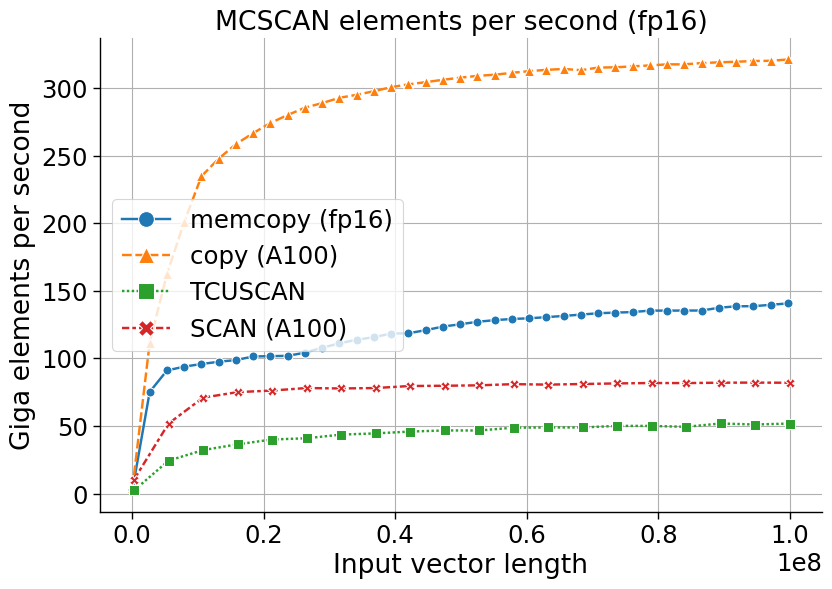

<Figure size 870x627 with 0 Axes>

In [5]:
ax = sns.lineplot(data=df, x='size', y='gelemps', **_SNS_PARAMS)

ax.set_title(f"MCSCAN elements per second ({dtype})")
ax.set_xlabel("Input vector length")
ax.set_ylabel("Giga elements per second")
sns.despine(right = True)
plt.legend(markerscale=_LEGEND_MARKER_SCALE)
plt.grid()
plt.tight_layout()

fig = ax.get_figure()
fig.savefig(f"figs/mcscan_gelemsps_{dtype}.png")
plt.show()
plt.clf()

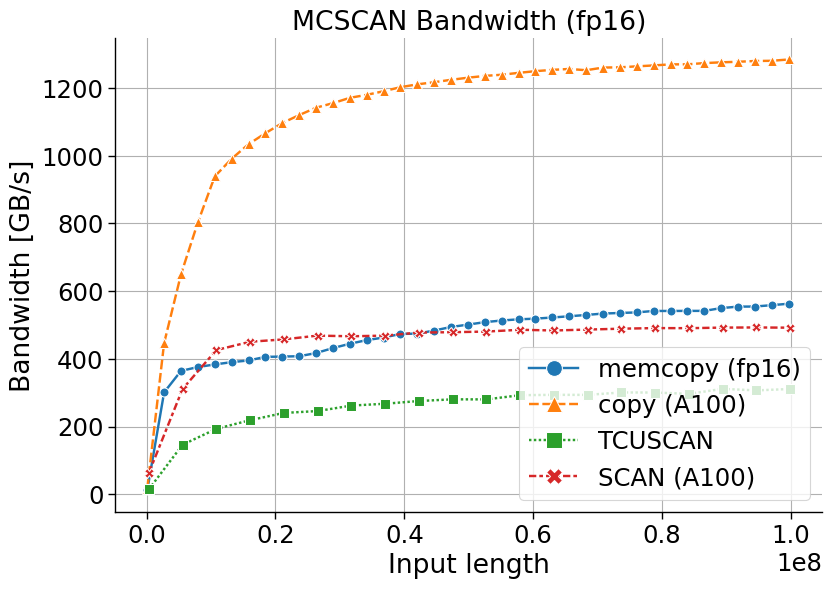

<Figure size 870x627 with 0 Axes>

In [6]:
ax = sns.lineplot(data=df, x='size', y='bw_gbps', **_SNS_PARAMS)

ax.set_title(f"MCSCAN Bandwidth ({dtype})")
ax.set_xlabel("Input length")
ax.set_ylabel("Bandwidth [GB/s]")
sns.despine(right = True)
plt.legend(markerscale=_LEGEND_MARKER_SCALE)
plt.grid()

plt.tight_layout()

fig = ax.get_figure()
fig.savefig(f"figs/mcscan_bw_{dtype}.png")
plt.show()
plt.clf()


In [7]:
df.head(100)

,operator,dtype,size,density,outputsize,time_us,S,in_bytes_per_elem,mem_bytes,gelemps,bw_gbps
0,copy_fp16,fp16,81920,NaN,81920,28.93,memcopy (fp16),2,327680,2.831663,11.326651
1,copy_fp16,fp16,2703360,NaN,2703360,35.94,memcopy (fp16),2,10813440,75.218698,300.874791
2,copy_fp16,fp16,5324800,NaN,5324800,58.46,memcopy (fp16),2,21299200,91.084502,364.338009
3,copy_fp16,fp16,7946240,NaN,7946240,84.60,memcopy (fp16),2,31784960,93.927187,375.708747
4,copy_fp16,fp16,10567680,NaN,10567680,110.25,memcopy (fp16),2,42270720,95.851973,383.407891
...,...,...,...,...,...,...,...,...,...,...,...
17,mcscan_128_fp16,fp16,89456640,NaN,89456640,1724.55,TCUSCAN,2,536739840,51.872454,311.234722
18,mcscan_128_fp16,fp16,94699520,NaN,94699520,1852.47,TCUSCAN,2,568197120,51.120677,306.724060
19,mcscan_128_fp16,fp16,99942400,NaN,99942400,1928.49,TCUSCAN,2,599654400,51.824173,310.945040
0,scan_fp16,fp16,327680,NaN,327680,31.42,SCAN (A100),2,1966080,10.429026,62.574157


In [8]:
max_size = df["size"].max()
df[df["size"] >= 99 * 1e6].head(20)

,operator,dtype,size,density,outputsize,time_us,S,in_bytes_per_elem,mem_bytes,gelemps,bw_gbps
38,copy_fp16,fp16,99696640,NaN,99696640,708.58,memcopy (fp16),2,398786560,140.699201,562.796805
38,copy_fp16,fp16,99696640,NaN,99696640,310.46,copy (A100),2,398786560,321.125556,1284.502223
19,mcscan_128_fp16,fp16,99942400,NaN,99942400,1928.49,TCUSCAN,2,599654400,51.824173,310.945040
19,scan_fp16,fp16,99942400,NaN,99942400,1218.73,SCAN (A100),2,599654400,82.005366,492.032197
